In [1]:
from dotenv import load_dotenv

from ingestion_simplified import fig_stats

load_dotenv()

True

In [7]:
import os

os.environ.setdefault("GEMINI_API_KEY", "")
os.environ.setdefault("PINECONE_API_KEY", "")

# Read once at import time, so set these before importing the rag package.
os.environ.setdefault("CHUNK_TOKEN_TARGET", "1024")     # chunk size, in tokens
os.environ.setdefault("FIGURE_AREA_THRESHOLD", "0.01")  # min page fraction for a figure
os.environ.setdefault("REPORT_DIR", "reports")

'reports'

In [8]:
import json
from pathlib import Path

import pandas as pd

from rag import chunking, clients, config, docling_io, tables
from rag import index as index_module
from rag import inspect as inspection
from rag import sync as sync_module

SOURCE_PDF = Path("pdfs/AI-Enablers-Adopters-research-report.pdf")

# Set to your bucket to store figure images and share the parse cache.
# Leave as None to keep everything local.
BUCKET = None

DOC_ID = config.slugify(SOURCE_PDF.stem)

print(f"document   : {DOC_ID}")
print(f"embedding  : {config.EMBED_MODEL} ({clients.EMBED_DIMS}d)")
print(f"chunk size : {config.CHUNK_TOKENS} tokens")
print(f"vision     : {config.VISION_MODEL}")
print(f"reports    : {config.REPORT_DIR.resolve()}")

document   : ai-enablers-adopters-research-report
embedding  : gemini-embedding-001 (3072d)
chunk size : 1024 tokens
vision     : gemini-3.6-flash
reports    : E:\vs-langchain-agents\05-rag\reports


In [9]:
import os
from google import genai

client = genai.Client(
    api_key=os.environ["GEMINI_API_KEY"]
)

response = client.models.embed_content(
    model="gemini-embedding-001",
    contents="test"
)

print("Gemini is working")
print("Embedding dimension:", len(response.embeddings[0].values))

Gemini is working
Embedding dimension: 3072


In [10]:
from docling.datamodel.pipeline_options import PdfPipelineOptions

# What this Docling build supports, and what it defaults to. Flag names move
# between releases, which is why rag.docling_io reads them rather than assuming.
for name, field in sorted(PdfPipelineOptions.model_fields.items()):
    if name.startswith(("do_", "generate_", "enable_")):
        print(f"  {name:36s} {field.default}")

  do_chart_extraction                  False
  do_code_enrichment                   False
  do_formula_enrichment                False
  do_ocr                               True
  do_picture_classification            False
  do_picture_description               False
  do_table_structure                   True
  enable_remote_services               False
  generate_page_images                 False
  generate_parsed_pages                False
  generate_picture_images              False
  generate_table_images                False


In [11]:
doc=docling_io.parse_pdf(SOURCE_PDF)

  enrichments: do_formula_enrichment, do_code_enrichment, do_picture_classification, do_picture_description, generate_picture_images, generate_table_images, enable_remote_services, do_chart_extraction
  vision model: gemini-3.6-flash
  vision provider: Google Gemini


Loading weights:   0%|          | 0/360 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.


Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie model.text_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.
Error calling the API. status=429 content_type=application/json; charset=UTF-8 response='[{\n  "error": {\n    "code": 429,\n    "message": "You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3.6-flash\\nPlease retry in 24.003077199s.",\n    "status": "RESOURCE_EXHAUSTED",\n    ...'
Error calling the API. status=429 content_type=application/json; charset=UTF-8 respon

  parsed in 110s  (16s per page)


In [12]:
markdown=doc.export_to_markdown()
doc_date=chunking.document_date(SOURCE_PDF,markdown[:4000])
print(f"pages {len(doc.pages)} document date: {doc_date}")

pages 7 document date: 2025


In [13]:
i=0
for item,level in doc.iterate_items():
    print(item)
    print(level)
    i=i+1
    print("---------------------")
    if i==2:
        break

self_ref='#/texts/0' parent=RefItem(cref='#/body') children=[] content_layer=<ContentLayer.BODY: 'body'> meta=None label=<DocItemLabel.TEXT: 'text'> prov=[ProvenanceItem(page_no=1, bbox=BoundingBox(l=42.0, t=762.278, r=288.052, b=712.6304189063948, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 30))] source=[] comments=[] orig='M January 6, 2025 10:00 PM GMT' text='M January 6, 2025 10:00 PM GMT' formatting=None hyperlink=None
1
---------------------
self_ref='#/texts/1' parent=RefItem(cref='#/body') children=[] content_layer=<ContentLayer.BODY: 'body'> meta=None label=<DocItemLabel.SECTION_HEADER: 'section_header'> prov=[ProvenanceItem(page_no=1, bbox=BoundingBox(l=42.0, t=711.342, r=104.062, b=697.65525, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 9))] source=[] comments=[] orig='Thematics' text='Thematics' formatting=None hyperlink=None level=1
1
---------------------


In [14]:
from docling_core.types.doc import PictureItem, TableItem


def preview(value, width: int = 88) -> str:
    """One line describing a field's value: its type, size, and a readable sample."""
    if value is None:
        return "None"
    if isinstance(value, (str, int, float, bool)):
        text = str(value).replace("\n", " ")
        return f"{text[:width]}{'…' if len(text) > width else ''}"
    if isinstance(value, (list, tuple)):
        if not value:
            return f"{type(value).__name__}[0] (empty)"
        inner = type(value[0]).__name__
        return f"{type(value).__name__}[{len(value)}] of {inner}"
    if isinstance(value, dict):
        return f"dict[{len(value)}] keys={list(value)[:6]}"
    return type(value).__name__


def dump_fields(obj, indent: str = "  ") -> None:
    """Print every declared field of a pydantic object, with its type and value.

    Docling's items are pydantic models, so `model_fields` is the authoritative
    list — better than dir(), which mixes in methods and validators. The fallback
    covers anything that is not a model.
    """
    fields = getattr(type(obj), "model_fields", None)
    if fields:
        for name in fields:
            value = getattr(obj, name, None)
            annotation = fields[name].annotation
            type_name = getattr(annotation, "__name__", str(annotation))
            print(f"{indent}{name:<18} {str(type_name)[:34]:<36} {preview(value)}")
    else:
        for name, value in vars(obj).items():
            if not name.startswith("_"):
                print(f"{indent}{name:<18} {type(value).__name__:<36} {preview(value)}")


seen = {}
for item, level in doc.iterate_items():
    label = str(getattr(item, "label", "?")).rsplit(".", 1)[-1]
    seen.setdefault(label, (item, level))

print(f"{len(seen)} element types found: {', '.join(sorted(seen))}\n")

for label in sorted(seen):
    item, level = seen[label]

    print("=" * 100)
    print(f"{label}   ({type(item).__name__}, tree level {level})")
    print("=" * 100)

    print("\nFIELDS")
    print(f"  {'name':<18} {'declared type':<36} value")
    print(f"  {'-'*18} {'-'*36} {'-'*40}")
    dump_fields(item)

    # prov is a list of provenance records, one per page the element appears on.
    # Its fields are where page numbers and bounding boxes actually live.
    prov = (getattr(item, "prov", None) or [None])[0]
    if prov is not None:
        print("\nprov[0]")
        dump_fields(prov, indent="  ")
        bbox = getattr(prov, "bbox", None)
        if bbox is not None:
            print("\n  prov[0].bbox")
            dump_fields(bbox, indent="    ")

    # Type-specific structure that the field list only hints at.
    if isinstance(item, TableItem):
        data = getattr(item, "data", None)
        if data is not None:
            print("\ndata  (the grid itself)")
            dump_fields(data, indent="  ")
            cells = getattr(data, "table_cells", None) or []
            if cells:
                print("\n  data.table_cells[0]")
                dump_fields(cells[0], indent="    ")
        markdown = item.export_to_markdown(doc)
        print(f"\nexport_to_markdown()  —  {len(tables.table_cells(markdown))} cells, "
              f"structure {tables.table_looks_broken(markdown) or 'looks sound'}")
        for line in markdown.splitlines()[:4]:
            print(f"  {line[:96]}")

    elif isinstance(item, PictureItem):
        annotations = docling_io.picture_annotations(item)
        print(f"\nannotations  —  {len(annotations)}")
        for n, annotation in enumerate(annotations):
            print(f"\n  annotations[{n}]  ({type(annotation).__name__})")
            dump_fields(annotation, indent="    ")
        print(f"\nget_image(doc) : "
              f"{'a PIL image' if item.get_image(doc) is not None else 'None — not rendered'}")

    print()

6 element types found: caption, list_item, picture, section_header, table, text

caption   (TextItem, tree level 2)

FIELDS
  name               declared type                        value
  ------------------ ------------------------------------ ----------------------------------------
  self_ref           str                                  #/texts/8
  parent             Optional                             RefItem
  children           list                                 list[0] (empty)
  content_layer      ContentLayer                         ContentLayer.BODY
  meta               Optional                             None
  label              Literal                              caption
  prov               list                                 list[1] of ProvenanceItem
  source             list                                 list[0] (empty)
  comments           list                                 list[0] (empty)
  orig               str                                  Exhibit 1 

C:\Users\Admin new\AppData\Local\Temp\ipykernel_10084\1676499447.py:31: DeprecationWarning: Field `annotations` is deprecated; use `meta` instead.
  value = getattr(obj, name, None)
C:\Users\Admin new\AppData\Local\Temp\ipykernel_10084\1676499447.py:31: DeprecationWarning: Field `annotations` is deprecated; use `meta` instead.
  value = getattr(obj, name, None)


self_ref='#/texts/0' parent=RefItem(cref='#/body') children=[] content_layer=<ContentLayer.BODY: 'body'> meta=None label=<DocItemLabel.TEXT: 'text'> prov=[ProvenanceItem(page_no=1, bbox=BoundingBox(l=42.0, t=762.278, r=288.052, b=712.6304189063948, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 30))] source=[] comments=[] orig='M January 6, 2025 10:00 PM GMT' text='M January 6, 2025 10:00 PM GMT' formatting=None hyperlink=None
1
self_ref='#/texts/1' parent=RefItem(cref='#/body') children=[] content_layer=<ContentLayer.BODY: 'body'> meta=None label=<DocItemLabel.SECTION_HEADER: 'section_header'> prov=[ProvenanceItem(page_no=1, bbox=BoundingBox(l=42.0, t=711.342, r=104.062, b=697.65525, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 9))] source=[] comments=[] orig='Thematics' text='Thematics' formatting=None hyperlink=None level=1
1
self_ref='#/texts/2' parent=RefItem(cref='#/body') children=[] content_layer=<ContentLayer.BODY: 'body'> meta=None la
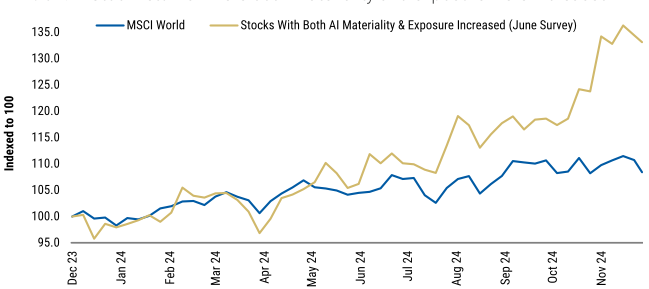
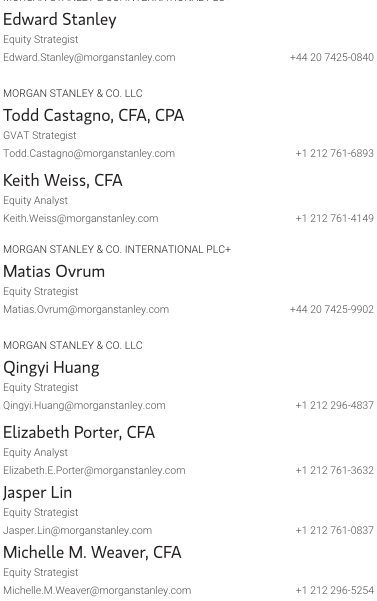
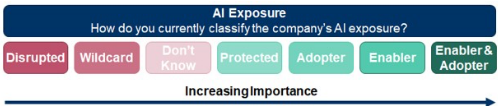

In [10]:
i = 0
for item, level in doc.iterate_items():

    i = i + 1
    print(item)
    print(level)
    if i == 21:
        break

self_ref='#/pictures/4' parent=RefItem(cref='#/body') children=[RefItem(cref='#/texts/94')] content_layer=<ContentLayer.BODY: 'body'> meta=PictureMeta(summary=None, language=None, entities=None, keywords=None, topics=None, description=DescriptionMetaField(confidence=None, created_by='not-implemented', text=''), classification=PictureClassificationMetaField(predictions=[PictureClassificationPrediction(confidence=0.9319209456443787, created_by='DocumentPictureClassifier', class_name='flow_chart'), PictureClassificationPrediction(confidence=0.025847479701042175, created_by='DocumentPictureClassifier', class_name='line_chart'), PictureClassificationPrediction(confidence=0.019170431420207024, created_by='DocumentPictureClassifier', class_name='engineering_drawing'), PictureClassificationPrediction(confidence=0.006326412782073021, created_by='DocumentPictureClassifier', class_name='bar_chart'), PictureClassificationPrediction(confidence=0.003483215579763055, created_by='DocumentPictureClassi
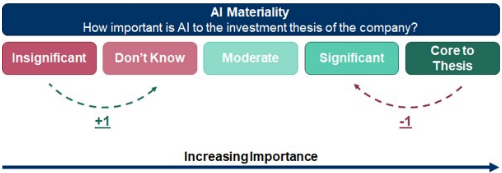

In [10]:
i = 0

for item, level in doc.iterate_items():
    if i == 29:
        print(item)
        print(level)
        break
    i += 1

In [15]:
    report=inspection.inspect(doc,markdown)

  pages=7  tables=3  tables_suspect=1  pictures=17  pictures_described=0  charts_with_data=0  formulas_undecoded=0


In [12]:
inspection.write_extraction_report(doc,DOC_ID,SOURCE_PDF)

  extraction report: reports\ai-enablers-adopters-research-report.extract.md
  18 extraction problems — see the report


WindowsPath('reports/ai-enablers-adopters-research-report.extract.md')

In [16]:
markdown = doc.export_to_markdown()

In [17]:
inspection.inspect(
    doc,
    markdown
)

  pages=7  tables=3  tables_suspect=1  pictures=17  pictures_described=0  charts_with_data=0  formulas_undecoded=0


{'pages': 7,
 'tables': 3,
 'tables_suspect': 1,
 'pictures': 17,
 'pictures_described': 0,
 'charts_with_data': 0,
 'formulas_undecoded': 0}

In [19]:
report_path=inspection.write_extraction_report(doc,DOC_ID,SOURCE_PDF)
print(report_path.read_text()[:2000])

  extraction report: reports\ai-enablers-adopters-research-report.extract.md
  18 extraction problems — see the report
# ai-enablers-adopters-research-report

- source: `AI-Enablers-Adopters-research-report.pdf`
- extracted: 2026-09-04T10:15:36+00:00
- vision model: `gemini-3.6-flash`
- pages: 7

## Extraction problems

- p1: figure 8 has no Gemini description
- p1: figure 11 has no Gemini description
- p2: figure 20 has no Gemini description
- p2: figure 23 has no Gemini description
- p2: figure 29 has no Gemini description
- p2: figure 32 has no Gemini description
- p3: figure 37 has no Gemini description
- p3: figure 39 has no Gemini description
- p3: figure 42 has no Gemini description
- p3: figure 45 has no Gemini description
- p3: figure 48 has no Gemini description
- p3: figure 51 has no Gemini description
- p4: figure 68 has no Gemini description
- p5: figure 73 has no Gemini description
- p5: figure 77 has no Gemini description
- p6: table 85 structure looks wrong (duplicate a

In [20]:
        # The same inventory as data, for checking a whole corpus at once rather than
# reading twenty reports.
inventory = json.loads(report_path.with_suffix(".json").read_text())

figure_elements = [e for e in inventory["elements"] if e["kind"] == "FIGURE"]
# Named `table_elements`, not `tables` — `tables` is an imported module,
# and rebinding it here breaks every later cell that calls
# tables.table_cells(). The failure looks like a missing attribute
# on a list, several cells away from the line that caused it.
table_elements = [e for e in inventory["elements"] if e["kind"] == "TABLE"]

print(f"{inventory['doc_id']}: {inventory['pages']} pages")
print(f"elements: {inventory['counts']}\n")
print(f"figures described : {sum(1 for f in figure_elements if f.get('description'))}/{len(figure_elements)}")
print(f"charts with data  : {sum(1 for f in figure_elements if f.get('has_chart_data'))}/{len(figure_elements)}")
print(f"tables serialised : {sum(1 for t in table_elements if t.get('cells', 0) > 0)}/{len(table_elements)}")
print(f"tables suspect    : {sum(1 for t in table_elements if t.get('structure_problems'))}/{len(table_elements)}")

if inventory["problems"]:
    print("\nproblems:")
    for problem in inventory["problems"]:
        print(f"  {problem}")
else:
    print("\nno extraction problems detected")

ai-enablers-adopters-research-report: 7 pages
elements: {'TEXT': 48, 'SECTION_HEADER': 14, 'FIGURE': 17, 'CAPTION': 15, 'TABLE': 3, 'LIST_ITEM': 10}

figures described : 0/17
charts with data  : 0/17
tables serialised : 3/3
tables suspect    : 1/3

problems:
  p1: figure 8 has no Gemini description
  p1: figure 11 has no Gemini description
  p2: figure 20 has no Gemini description
  p2: figure 23 has no Gemini description
  p2: figure 29 has no Gemini description
  p2: figure 32 has no Gemini description
  p3: figure 37 has no Gemini description
  p3: figure 39 has no Gemini description
  p3: figure 42 has no Gemini description
  p3: figure 45 has no Gemini description
  p3: figure 48 has no Gemini description
  p3: figure 51 has no Gemini description
  p4: figure 68 has no Gemini description
  p5: figure 73 has no Gemini description
  p5: figure 77 has no Gemini description
  p6: table 85 structure looks wrong (duplicate adjacent header cells)
  p6: figure 88 has no Gemini description

In [21]:
# Read one figure description against the actual chart. This is the only check on
# whether the vision model read the numbers or wrote plausible prose about them.
for figure in figure_elements:
    if figure.get("description"):
        print(f"FIGURE p{figure['page']}\n{figure['description']}\n")
        break

# And one table, with any structure warning attached.
for table in table_elements:
    if table.get("markdown"):
        print(f"TABLE p{table['page']}  {table['cells']} cells")
        if table.get("structure_problems"):
            print(f"  STRUCTURE SUSPECT: {'; '.join(table['structure_problems'])}")
        print(table["markdown"][:900])
        break

TABLE p1  16 cells
| Edward Stanley Equity Strategist Edward.Stanley@morganstanley.com                                     | +44 20 7425-0840   |
|-------------------------------------------------------------------------------------------------------|--------------------|
| Todd Castagno, CFA, CPA GVAT Strategist Todd.Castagno@morganstanley.com                               | +1 212 761-6893    |
| Keith Weiss, CFA Equity Analyst Keith.Weiss@morganstanley.com                                         | +1 212 761-4149    |
| Morgan Stanley & Co. International plc+ Matias Ovrum Equity Strategist Matias.Ovrum@morganstanley.com | +44 20 7425-9902   |
| Qingyi Huang Equity Strategist Qingyi.Huang@morganstanley.com                                         | +1 212 296-4837    |
| Elizabeth Porter, CFA Equity Analyst Elizabeth.E.Porter@morganstanley.com                             | +1 212 761-3632    |
| Jasper Li


In [22]:
figure_uris=docling_io.save_figures(doc,DOC_ID,BUCKET)
print(f"{len(figure_uris)} figures images stored")

0 figures images stored


In [24]:
records=chunking.build_records(doc,SOURCE_PDF,DOC_ID,doc_date,figure_uris)

  10 heading(s) remain


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (905 > 512). Running this sequence through the model will result in indexing errors


  Docling chunks: 75
  Entries before merge: 55
  Dropped furniture: 20
  Prose merges: 26
  Floor merges: 0

Final records: 14
Docling chunks: 75
Tables extracted: 3
Tables summarised: 2 / 3
Floor merges: 0
Prose merges: 26
Dropped furniture: 20
Types: {'text': 10, 'table_summary': 2, 'table': 2}
Median tokens: 297
Under 50 tokens: 1
Maximum tokens: 1024
    dropped p2: a single glyph: M
    dropped p2: an attribution line: Source: Morgan Stanley Research
    dropped p2: an attribution line: Source: Morgan Stanley Research
    dropped p3: a single glyph: M
    dropped p3: an attribution line: Source: FactSet, Morgan Stanley Research
    dropped p3: an attribution line: Source: FactSet, Morgan Stanley Research
    dropped p3: an attribution line: Source: FactSet, Morgan Stanley Research
    dropped p3: an attribution line: Source: FactSet, Morgan Stanley Research
    dropped p3: an attribution line: Source: FactSet, Morgan Stanley Research
    dropped p3: an attribution line: Source: F

ValueError: too many values to unpack (expected 3)

In [25]:
from google import genai
import os

client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])

response = client.models.embed_content(
    model="gemini-embedding-001",
    contents="Hello world"
)

embedding = response.embeddings[0].values

print(len(embedding))

3072


In [26]:
from transformers import AutoTokenizer

from docling_core.transforms.chunker.tokenizer.huggingface import HuggingFaceTokenizer
from docling.chunking import HybridChunker


EMBED_MODEL_ID = "sentence-transformers/all-MiniLM-L6-v2"

tokenizer = HuggingFaceTokenizer(
    tokenizer=AutoTokenizer.from_pretrained(EMBED_MODEL_ID),
    max_tokens=256,
)

chunker = HybridChunker(
    tokenizer=tokenizer,
    merge_peers=False,
)

In [27]:
chunks = list(chunker.chunk(dl_doc=doc))

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1645 > 512). Running this sequence through the model will result in indexing errors


text='M January 6, 2025 10:00 PM GMT' meta=DocMeta(schema_name='docling_core.transforms.chunker.DocMeta', version='1.0.0', doc_items=[DocItem(self_ref='#/texts/0', parent=RefItem(cref='#/body'), children=[], content_layer=<ContentLayer.BODY: 'body'>, meta=None, label=<DocItemLabel.TEXT: 'text'>, prov=[ProvenanceItem(page_no=1, bbox=BoundingBox(l=42.0, t=762.278, r=288.052, b=712.6304189063948, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 30))], source=[], comments=[])], headings=None, captions=None, origin=DocumentOrigin(mimetype='application/pdf', binary_hash=17821704819454838090, filename='AI-Enablers-Adopters-research-report.pdf', uri=None))
text="More than two years since ChatGPT's launch, we remain in the early innings of AI's diffusion. This is the third iteration of the most comprehensive AI stock mapping exercise in the market. Rate of change continues to drive outperformance, and we believe 2025 will be the year of Agentic AI." meta=DocMeta(schema_name='d
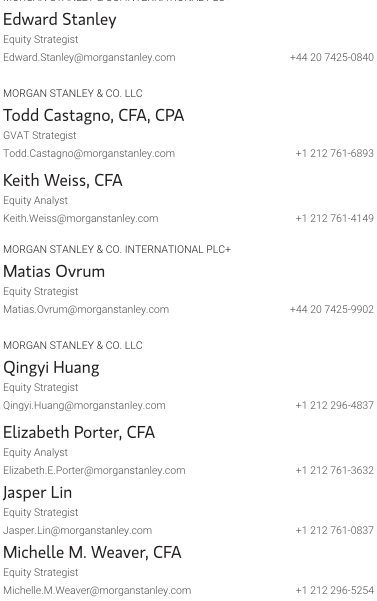
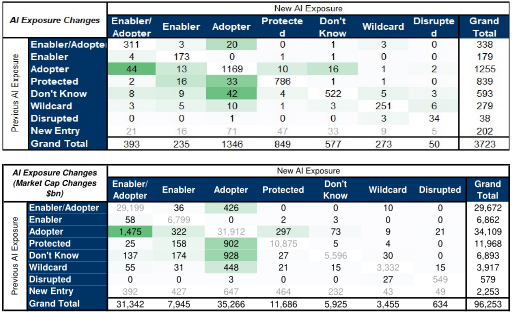
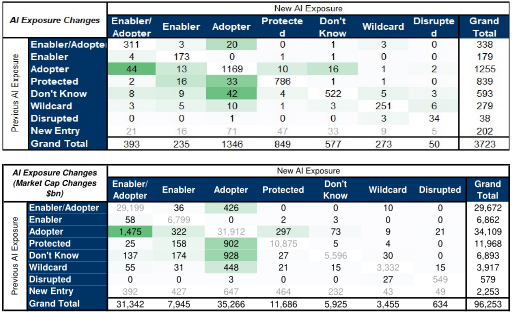
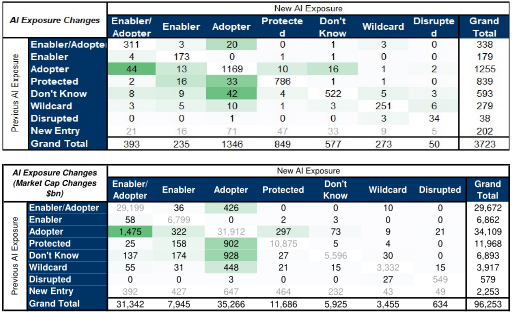
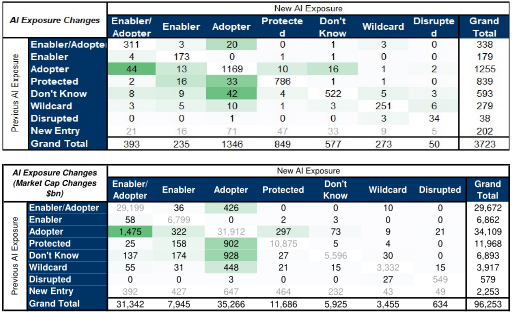
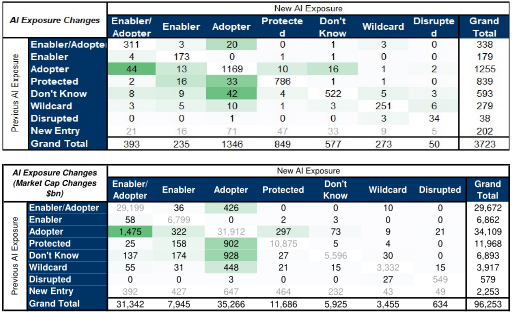
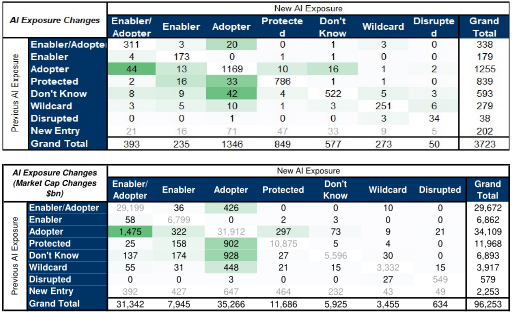
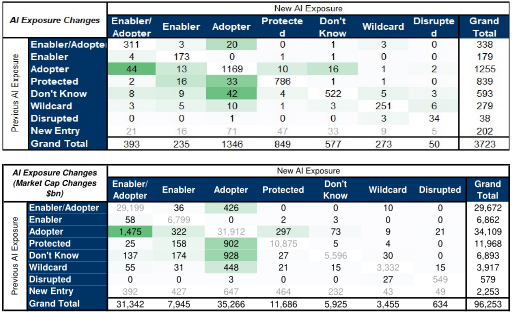

In [28]:
for chunk in chunks:
    print(chunk)
print("-------------------------------------")

In [27]:
for chunk in chunks:
    for chunk in chunks:
        if len(chunk.meta.doc_items)>1:
            print(chunk)
        print("-------------------------------")

-------------------------------
-------------------------------
-------------------------------
-------------------------------
-------------------------------
-------------------------------
text='Exhibit 1 : Stock returns where both materiality and exposure were increased\n\nBased on the image provided, here is the description for a search index\n\nLine chart' meta=DocMeta(schema_name='docling_core.transforms.chunker.DocMeta', version='1.0.0', doc_items=[DocItem(self_ref='#/texts/8', parent=RefItem(cref='#/pictures/0'), children=[], content_layer=<ContentLayer.BODY: 'body'>, meta=None, label=<DocItemLabel.CAPTION: 'caption'>, prov=[ProvenanceItem(page_no=1, bbox=BoundingBox(l=42.0, t=212.00400000000002, r=347.569, b=203.15843103448276, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 76))], source=[], comments=[]), DocItem(self_ref='#/pictures/0', parent=RefItem(cref='#/body'), children=[RefItem(cref='#/texts/8'), RefItem(cref='#/texts/9'), RefItem(cref='#/texts/10'

In [29]:
items_by_ref = {}

for item, _ in doc.iterate_items():
    ref = getattr(item, "self_ref", None)
    if ref:
        items_by_ref[ref] = item

In [30]:
print(type(items_by_ref))
items_by_ref['#/texts/1']

<class 'dict'>


SectionHeaderItem(self_ref='#/texts/1', parent=RefItem(cref='#/body'), children=[], content_layer=<ContentLayer.BODY: 'body'>, meta=None, label=<DocItemLabel.SECTION_HEADER: 'section_header'>, prov=[ProvenanceItem(page_no=1, bbox=BoundingBox(l=42.0, t=711.342, r=104.062, b=697.65525, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 9))], source=[], comments=[], orig='Thematics', text='Thematics', formatting=None, hyperlink=None, level=1)

key: #/texts/0
value: self_ref='#/texts/0' parent=RefItem(cref='#/body') children=[] content_layer=<ContentLayer.BODY: 'body'> meta=None label=<DocItemLabel.TEXT: 'text'> prov=[ProvenanceItem(page_no=1, bbox=BoundingBox(l=42.0, t=762.278, r=288.052, b=712.6304189063948, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 30))] source=[] comments=[] orig='M January 6, 2025 10:00 PM GMT' text='M January 6, 2025 10:00 PM GMT' formatting=None hyperlink=None
-----------------
key: #/texts/1
value: self_ref='#/texts/1' parent=RefItem(cref='#/body') children=[] content_layer=<ContentLayer.BODY: 'body'> meta=None label=<DocItemLabel.SECTION_HEADER: 'section_header'> prov=[ProvenanceItem(page_no=1, bbox=BoundingBox(l=42.0, t=711.342, r=104.062, b=697.65525, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 9))] source=[] comments=[] orig='Thematics' text='Thematics' formatting=None hyperlink=None level=1
-----------------
key: #/texts/2
value: self_ref='#/texts/2
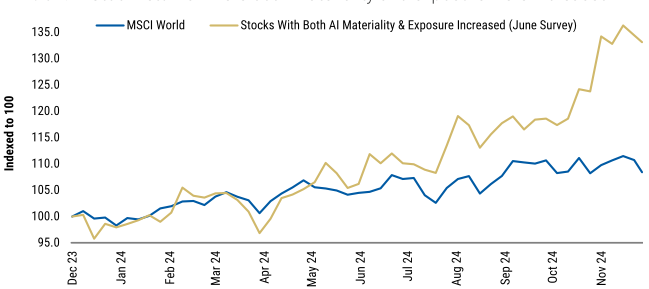
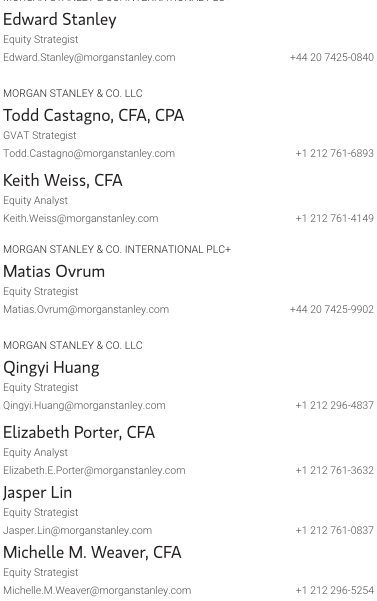
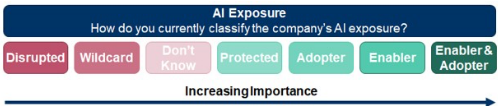
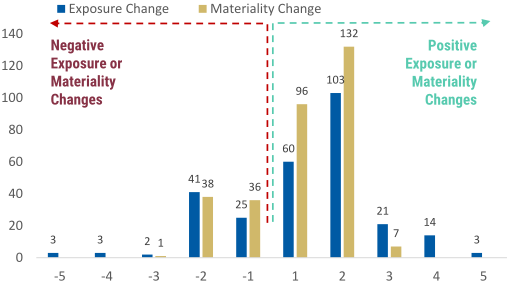
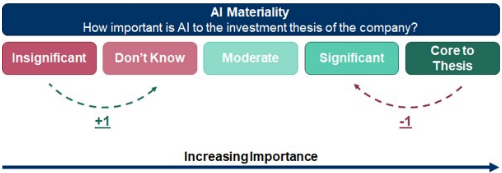
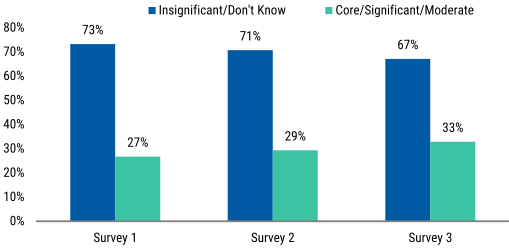
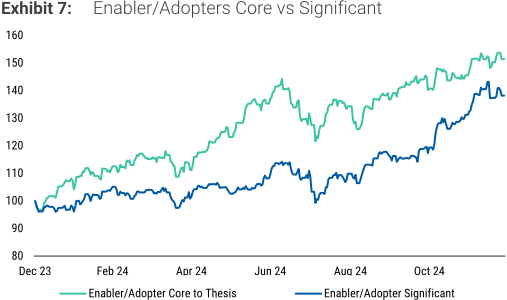
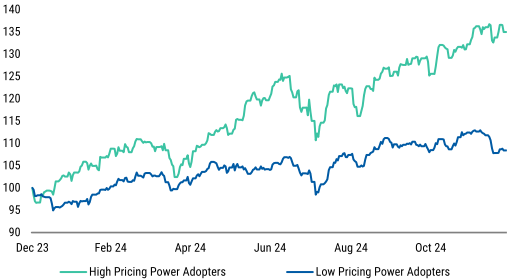
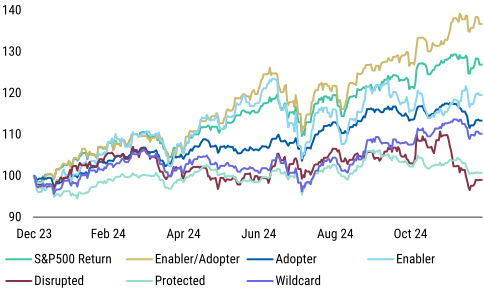
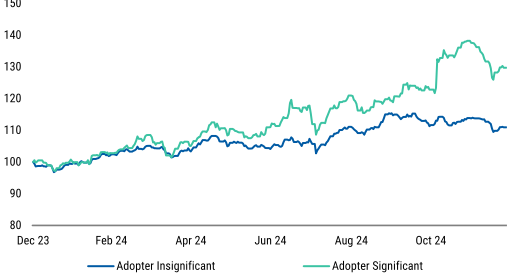
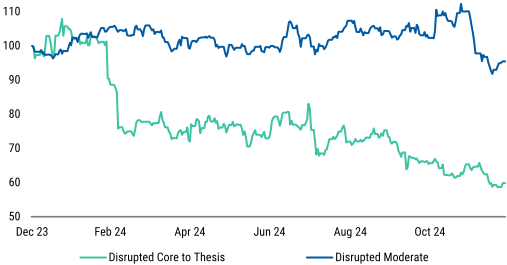
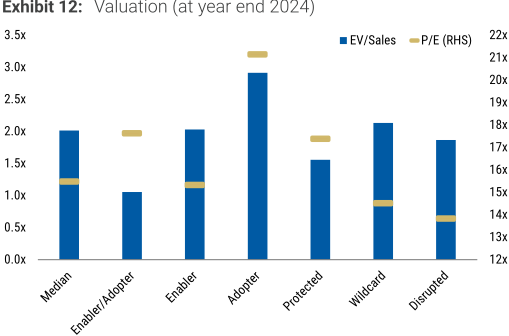
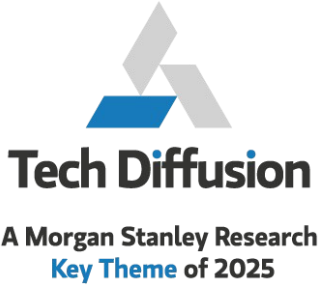
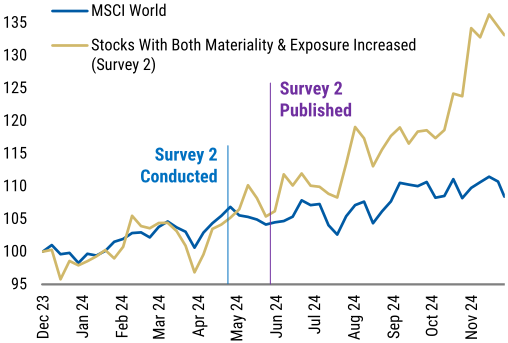
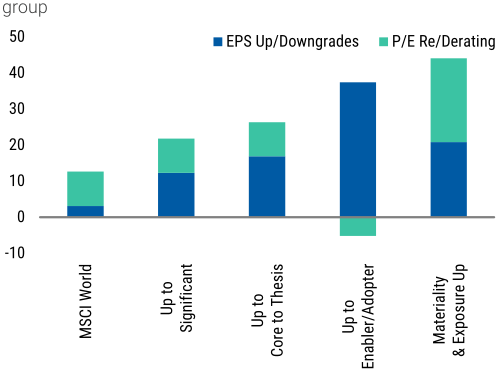
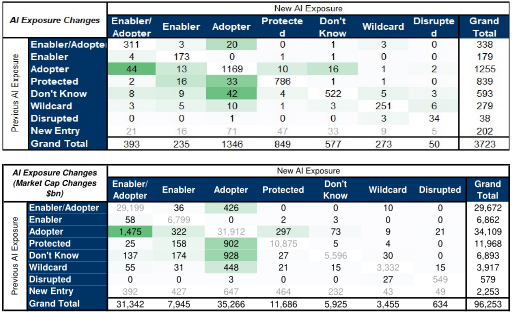
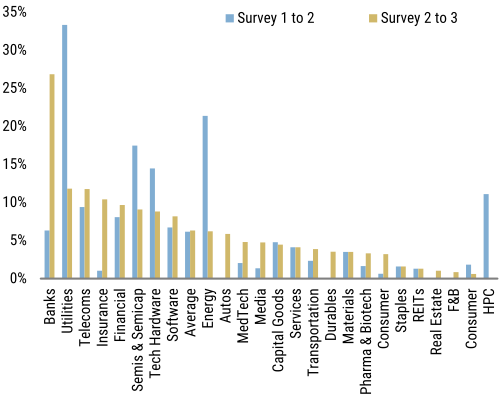
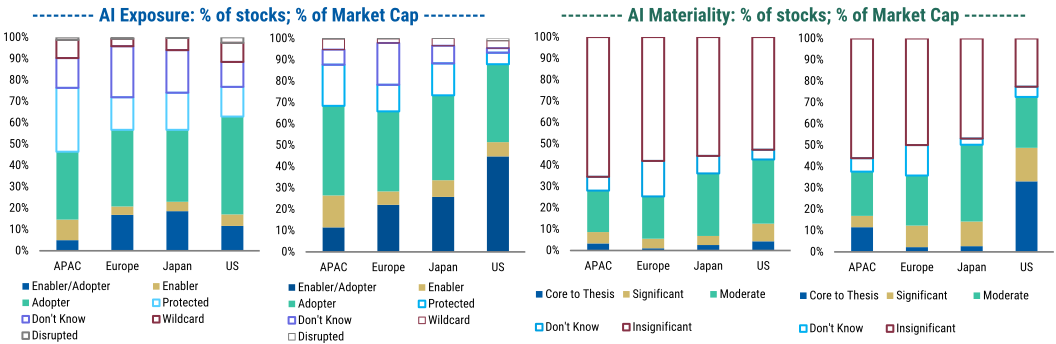
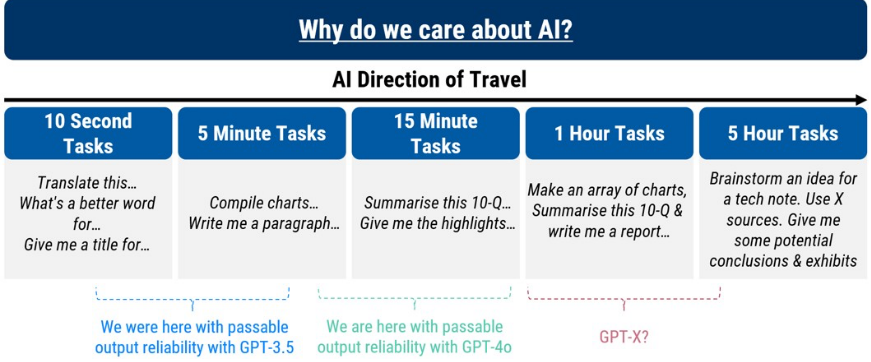

In [31]:
for key,value in items_by_ref.items():
    print("key:",key)
    print("value:",value)
    print("-----------------")

In [32]:
chunks[0]

DocChunk(text='M January 6, 2025 10:00 PM GMT', meta=DocMeta(schema_name='docling_core.transforms.chunker.DocMeta', version='1.0.0', doc_items=[DocItem(self_ref='#/texts/0', parent=RefItem(cref='#/body'), children=[], content_layer=<ContentLayer.BODY: 'body'>, meta=None, label=<DocItemLabel.TEXT: 'text'>, prov=[ProvenanceItem(page_no=1, bbox=BoundingBox(l=42.0, t=762.278, r=288.052, b=712.6304189063948, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 30))], source=[], comments=[])], headings=None, captions=None, origin=DocumentOrigin(mimetype='application/pdf', binary_hash=17821704819454838090, filename='AI-Enablers-Adopters-research-report.pdf', uri=None)))

In [33]:
from rag.tables import table_ref_of
from rag.chunking import content_type, is_furniture

"""
DocChunk(text='M January 6, 2025 10:00 PM GMT', meta=DocMeta(schema_name='docling_core.transforms.chunker.DocMeta', version='1.0.0', doc_items=[DocItem(self_ref='#/texts/0', parent=RefItem(cref='#/body'), children=[], content_layer=<ContentLayer.BODY: 'body'>, meta=None, label=<DocItemLabel.TEXT: 'text'>, prov=[ProvenanceItem(page_no=1, bbox=BoundingBox(l=42.0, t=762.278, r=288.052, b=712.6304189063948, coord_origin=<CoordOrigin.BOTTOMLEFT: 'BOTTOMLEFT'>), charspan=(0, 30))], source=[], comments=[])], headings=None, captions=None, origin=DocumentOrigin(mimetype='application/pdf', binary_hash=17821704819454838090, filename='AI-Enablers-Adopters-research-report.pdf', uri=None)))
"""

entries, dropped = [], []

for chunk in chunks:
    items = chunk.meta.doc_items
    headings = list(chunk.meta.headings or [])

    pages = sorted({
        prov.page_no
        for item in items
        for prov in (getattr(item, "prov", []) or [])
    })

    page = pages[0] if pages else -1
    page_end = pages[-1] if pages else -1
    #print(page,page_end)

    labels = [str(getattr(i, "label", "")).lower() for i in items]
    pictures = [i for i, label in zip(items, labels) if "picture" in label]
    beside = [label for label in labels if "picture" not in label]
    print(labels)
    print(pictures)
    print(beside)
    print("-----------")

    if pictures and all("caption" in label for label in beside):
        entries.append({
            "kind": "figure_slot",
            "refs": [
                getattr(i, "self_ref", None)
                for i in pictures
                if getattr(i, "self_ref", None)
            ],
            "head": headings,
            "page": page,
            "page_end": page_end,
        })
        continue

    kind = content_type(chunk)

    # Text only. A table or a figure is never dropped.
    if kind == "text":
        # is header or footer
        reason = is_furniture(chunk.text)

        if reason:
            dropped.append(
                (page, reason, chunk.text.strip()[:60])
            )
            continue

    image_uri = ""

    for item in items:
        key = getattr(item, "self_ref", None)

        if key and key in (figure_uris or {}):
            image_uri = figure_uris[key]
            break

    entries.append({
        "kind": kind,
        "body": chunk.text,
        # Kept for entries that survive unmerged, so their embedded text
        # is byte-identical to what the chunker would have produced.
        "contextualized": chunker.contextualize(chunk),
        "merged": False,
        "head": headings,
        "page": page,
        "page_end": page_end,
        "ref": table_ref_of(chunk),
        "image_uri": image_uri,
    })

['text']
[]
['text']
-----------
['text']
[]
['text']
-----------
['text']
[]
['text']
-----------
['text']
[]
['text']
-----------
['text']
[]
['text']
-----------
['text']
[]
['text']
-----------
['caption', 'picture']
[DocItem(self_ref='#/pictures/0', parent=RefItem(cref='#/body'), children=[RefItem(cref='#/texts/8'), RefItem(cref='#/texts/9'), RefItem(cref='#/texts/10'), RefItem(cref='#/texts/11'), RefItem(cref='#/texts/12'), RefItem(cref='#/texts/13'), RefItem(cref='#/texts/14'), RefItem(cref='#/texts/15'), RefItem(cref='#/texts/16'), RefItem(cref='#/texts/17'), RefItem(cref='#/texts/18'), RefItem(cref='#/texts/19'), RefItem(cref='#/texts/20'), RefItem(cref='#/texts/21'), RefItem(cref='#/texts/22'), RefItem(cref='#/texts/23'), RefItem(cref='#/texts/24'), RefItem(cref='#/texts/25'), RefItem(cref='#/texts/26'), RefItem(cref='#/texts/27'), RefItem(cref='#/texts/28'), RefItem(cref='#/texts/29'), RefItem(cref='#/texts/30'), RefItem(cref='#/texts/31'), RefItem(cref='#/texts/32')], conte

In [34]:
print(entries[0])

{'kind': 'text', 'body': 'M January 6, 2025 10:00 PM GMT', 'contextualized': 'M January 6, 2025 10:00 PM GMT', 'merged': False, 'head': [], 'page': 1, 'page_end': 1, 'ref': None, 'image_uri': ''}


In [31]:
print("Number of chunks:", len(chunks))
print("Number of entries:", len(entries))
print("Number of dropped:", len(dropped))

Number of chunks: 79
Number of entries: 63
Number of dropped: 16


In [35]:
entries, dropped = [], []

for chunk in chunks:

    items = chunk.meta.doc_items
    headings = list(chunk.meta.headings or [])

    pages = sorted({
        prov.page_no
        for item in items
        for prov in (getattr(item, "prov", []) or [])
    })

    page = pages[0] if pages else -1
    page_end = pages[-1] if pages else -1

    kind = content_type(chunk)

    print("KIND:", kind)
    print("TEXT:", repr(chunk.text[:100]))

    if kind == "text":
        reason = is_furniture(chunk.text)

        print("FURNITURE:", reason)

        if reason:
            dropped.append(
                (page, reason, chunk.text.strip()[:60])
            )
            continue

    entries.append({
        "kind": kind,
        "body": chunk.text,
        "contextualized": chunker.contextualize(chunk),
        "merged": False,
        "head": headings,
        "page": page,
        "page_end": page_end,
        "ref": table_ref_of(chunk),
        "image_uri": "",
    })

print("entries:", len(entries))
print("dropped:", len(dropped))

KIND: text
TEXT: 'M January 6, 2025 10:00 PM GMT'
FURNITURE: None
KIND: text
TEXT: "More than two years since ChatGPT's launch, we remain in the early innings of AI's diffusion. This i"
FURNITURE: None
KIND: text
TEXT: "AI's Rate of Change Continues to Surprise: Our first AI Adopter survey was published in January 2024"
FURNITURE: None
KIND: text
TEXT: "AI's Rate of Change Has Driven Outperformance: Exhibit 1  shows the 2H24 outperformance of stocks wh"
FURNITURE: None
KIND: text
TEXT: '2025 - Agentic AI Adopters: As in previous tech cycles, the equity markets are poised for Semiconduc'
FURNITURE: None
KIND: text
TEXT: 'process is underway. Simply put, AI Agents give "agency" to software programs. In "chatbot phase" to'
FURNITURE: None
KIND: figure
TEXT: 'Exhibit 1 : Stock returns where both materiality and exposure were increased\n\nLine chart'
KIND: text
TEXT: 'Source: Eikon, MS Research. Past performance is no guarantee of future results. Results shown do not'
FURNITURE: None
KIND: 

In [36]:
print(entries[0])
print("----")
print(entries[1])
print("---------")
print(entries[3])
print("---------------")
print(entries[6])
print("---------------")
print(entries[9])

{'kind': 'text', 'body': 'M January 6, 2025 10:00 PM GMT', 'contextualized': 'M January 6, 2025 10:00 PM GMT', 'merged': False, 'head': [], 'page': 1, 'page_end': 1, 'ref': None, 'image_uri': ''}
----
{'kind': 'text', 'body': "More than two years since ChatGPT's launch, we remain in the early innings of AI's diffusion. This is the third iteration of the most comprehensive AI stock mapping exercise in the market. Rate of change continues to drive outperformance, and we believe 2025 will be the year of Agentic AI.", 'contextualized': "Uncovering Alpha in AI's Rate of Change\nMore than two years since ChatGPT's launch, we remain in the early innings of AI's diffusion. This is the third iteration of the most comprehensive AI stock mapping exercise in the market. Rate of change continues to drive outperformance, and we believe 2025 will be the year of Agentic AI.", 'merged': False, 'head': ["Uncovering Alpha in AI's Rate of Change"], 'page': 1, 'page_end': 1, 'ref': None, 'image_uri': ''}
-

In [37]:
entries = [
    {
        'kind': 'text',
        'body': 'M January 6, 2025 10:00 PM GMT',
        'contextualized': 'M January 6, 2025 10:00 PM GMT',
        'merged': False,
        'head': [],
        'page': 1,
        'page_end': 1,
        'ref': None,
        'image_uri': ''
    },
    {
        'kind': 'text',
        'body': "More than two years since ChatGPT's launch, we remain in the early innings of AI's diffusion. This is the third iteration of the most comprehensive AI stock mapping exercise in the market. Rate of change continues to drive outperformance, and we believe 2025 will be the year of Agentic AI.",
        'contextualized': "Uncovering Alpha in AI's Rate of Change\nMore than two years since ChatGPT's launch, we remain in the early innings of AI's diffusion. This is the third iteration of the most comprehensive AI stock mapping exercise in the market. Rate of change continues to drive outperformance, and we believe 2025 will be the year of Agentic AI.",
        'merged': False,
        'head': ["Uncovering Alpha in AI's Rate of Change"],
        'page': 1,
        'page_end': 1,
        'ref': None,
        'image_uri': ''
    },
    {
        'kind': 'text',
        'body': "AI's Rate of Change Has Driven Outperformance: Exhibit 1 shows the 2H24 outperformance of stocks which previously saw their exposure and materiality increased. Looking forward, overweight rated stocks matching these criteria in this latest survey have 29% upside to price targets. We explain how to access and use our database and sees three opportunities ahead: (1) Enablers with rising materiality; (2) Adopters with pricing power; (3) Financials with AI 'Rate of Change' tailwinds.",
        'contextualized': "Uncovering Alpha in AI's Rate of Change\nAI's Rate of Change Has Driven Outperformance: Exhibit 1 shows the 2H24 outperformance of stocks which previously saw their exposure and materiality increased. Looking forward, overweight rated stocks matching these criteria in this latest survey have 29% upside to price targets. We explain how to access and use our database and sees three opportunities ahead: (1) Enablers with rising materiality; (2) Adopters with pricing power; (3) Financials with AI 'Rate of Change' tailwinds.",
        'merged': False,
        'head': ["Uncovering Alpha in AI's Rate of Change"],
        'page': 1,
        'page_end': 1,
        'ref': None,
        'image_uri': ''
    },
    {
        'kind': 'figure',
        'body': 'Exhibit 1 : Stock returns where both materiality and exposure were increased\n\nHere is a factual description of the image for a search index based strictly\n\nLine chart',
        'contextualized': "Uncovering Alpha in AI's Rate of Change\nExhibit 1 : Stock returns where both materiality and exposure were increased\n\nHere is a factual description of the image for a search index based strictly\n\nLine chart",
        'merged': False,
        'head': ["Uncovering Alpha in AI's Rate of Change"],
        'page': 1,
        'page_end': 1,
        'ref': None,
        'image_uri': ''
    },
    {
        'kind': 'table',
        'body': 'Edward Stanley Equity Strategist Edward.Stanley@morganstanley.com, 1 = +44 20 7425-0840. Todd Castagno, CFA, CPA GVAT Strategist Todd.Castagno@morganstanley.com, 1 = +1 212 761-6893. Keith Weiss, CFA Equity Analyst Keith.Weiss@morganstanley.com, 1 = +1 212 761-4149. Morgan Stanley & Co. International plc+ Matias Ovrum Equity Strategist Matias.Ovrum@morganstanley.com, 1 = +44 20 7425-9902. Qingyi Huang Equity Strategist Qingyi.Huang@morganstanley.com, 1 = +1 212 296-4837. Elizabeth Porter, CFA Equity Analyst Elizabeth.E.Porter@morganstanley.com, 1 = +1 212 761-3632. Jasper Lin Equity Strategist Jasper.Lin@morganstanley.com, 1 = +1 212 761-0837. Michelle M. Weaver, CFA Equity Strategist Michelle.M.Weaver@morganstanley.com, 1 = +1 212 296-5254',
        'contextualized': "Uncovering Alpha in AI's Rate of Change\nEdward Stanley Equity Strategist Edward.Stanley@morganstanley.com, 1 = +44 20 7425-0840. Todd Castagno, CFA, CPA GVAT Strategist Todd.Castagno@morganstanley.com, 1 = +1 212 761-6893. Keith Weiss, CFA Equity Analyst Keith.Weiss@morganstanley.com, 1 = +1 212 761-4149. Morgan Stanley & Co. International plc+ Matias Ovrum Equity Strategist Matias.Ovrum@morganstanley.com, 1 = +44 20 7425-9902. Qingyi Huang Equity Strategist Qingyi.Huang@morganstanley.com, 1 = +1 212 296-4837. Elizabeth Porter, CFA Equity Analyst Elizabeth.E.Porter@morganstanley.com, 1 = +1 212 761-3632. Jasper Lin Equity Strategist Jasper.Lin@morganstanley.com, 1 = +1 212 761-0837. Michelle M. Weaver, CFA Equity Strategist Michelle.M.Weaver@morganstanley.com, 1 = +1 212 296-5254",
        'merged': False,
        'head': ["Uncovering Alpha in AI's Rate of Change"],
        'page': 1,
        'page_end': 1,
        'ref': '#/tables/0',
        'image_uri': ''
    }
]

MERGE_ACROSS_EXHIBITS = False
PROSE_TARGET_TOKENS = 1000

out: list[dict] = []
merges = 0

for entry in entries:
    target = None

    if entry["kind"] == "text":
        for candidate in reversed(out):
            if candidate["head"] == entry["head"]:
                if candidate["kind"] == "text":
                    target = candidate
                    break

            if not MERGE_ACROSS_EXHIBITS:
                break

    if target is not None:
        combined_body = target["body"] + "\n" + entry["body"]

        if len(combined_body) <= PROSE_TARGET_TOKENS:
            target["body"] = combined_body
            target["page_end"] = max(
                target["page_end"],
                entry["page_end"]
            )
            target["merged"] = True
            target["image_uri"] = (
                target["image_uri"] or entry["image_uri"]
            )
            merges += 1
    else:
        out.append(entry)

out, merges

([{'kind': 'text',
   'body': 'M January 6, 2025 10:00 PM GMT',
   'contextualized': 'M January 6, 2025 10:00 PM GMT',
   'merged': False,
   'head': [],
   'page': 1,
   'page_end': 1,
   'ref': None,
   'image_uri': ''},
  {'kind': 'text',
   'body': "More than two years since ChatGPT's launch, we remain in the early innings of AI's diffusion. This is the third iteration of the most comprehensive AI stock mapping exercise in the market. Rate of change continues to drive outperformance, and we believe 2025 will be the year of Agentic AI.\nAI's Rate of Change Has Driven Outperformance: Exhibit 1 shows the 2H24 outperformance of stocks which previously saw their exposure and materiality increased. Looking forward, overweight rated stocks matching these criteria in this latest survey have 29% upside to price targets. We explain how to access and use our database and sees three opportunities ahead: (1) Enablers with rising materiality; (2) Adopters with pricing power; (3) Financials with 

In [38]:
print(out)

[{'kind': 'text', 'body': 'M January 6, 2025 10:00 PM GMT', 'contextualized': 'M January 6, 2025 10:00 PM GMT', 'merged': False, 'head': [], 'page': 1, 'page_end': 1, 'ref': None, 'image_uri': ''}, {'kind': 'text', 'body': "More than two years since ChatGPT's launch, we remain in the early innings of AI's diffusion. This is the third iteration of the most comprehensive AI stock mapping exercise in the market. Rate of change continues to drive outperformance, and we believe 2025 will be the year of Agentic AI.\nAI's Rate of Change Has Driven Outperformance: Exhibit 1 shows the 2H24 outperformance of stocks which previously saw their exposure and materiality increased. Looking forward, overweight rated stocks matching these criteria in this latest survey have 29% upside to price targets. We explain how to access and use our database and sees three opportunities ahead: (1) Enablers with rising materiality; (2) Adopters with pricing power; (3) Financials with AI 'Rate of Change' tailwinds.

In [39]:
from rag.headings import clean_headings

clean_headings(doc)

  10 heading(s) remain


[]

In [40]:
from rag.headings import clean_headings
clean_headings(doc)

  10 heading(s) remain


[]

In [41]:
print(dropped)

[(2, 'a single glyph', 'M'), (2, 'an attribution line', 'Source: Morgan Stanley Research'), (2, 'an attribution line', 'Source: Morgan Stanley Research'), (3, 'a single glyph', 'M'), (3, 'an attribution line', 'Source: FactSet, Morgan Stanley Research'), (3, 'an attribution line', 'Source: FactSet, Morgan Stanley Research'), (3, 'an attribution line', 'Source: FactSet, Morgan Stanley Research'), (3, 'an attribution line', 'Source: FactSet, Morgan Stanley Research'), (3, 'an attribution line', 'Source: FactSet, Morgan Stanley Research'), (3, 'an attribution line', 'Source: FactSet, Morgan Stanley Research'), (4, 'a single glyph', 'M'), (5, 'a single glyph', 'M'), (5, 'an attribution line', 'Source: Eikon, Morgan Stanley Research'), (5, 'an attribution line', 'Source: Eikon, Morgan Stanley Research'), (6, 'a single glyph', 'M'), (6, 'empty', ''), (6, 'an attribution line', 'Source: FactSet, Morgan Stanley Research'), (6, 'an attribution line', 'Source: Morgan Stanley Research'), (7, 'a s

In [42]:
from rag.chunking import _apply_floor

entries, floor_merges = _apply_floor(entries)

print("Entries after floor:", len(entries))
print("Floor merges:", floor_merges)

Entries after floor: 5
Floor merges: 0


In [49]:
from rag.chunking import _to_records, _record_factory

# ---------------------------------------------------------
# Build Docling item reference map
# ---------------------------------------------------------

items_by_ref = {}

for item, _ in doc.iterate_items():

    ref = getattr(
        item,
        "self_ref",
        None,
    )

    if ref:
        items_by_ref[ref] = item


# ---------------------------------------------------------
# Figure URI mapping
# ---------------------------------------------------------

figure_uris = {}


# ---------------------------------------------------------
# Record factory
# ---------------------------------------------------------

make = _record_factory(
    pdf=SOURCE_PDF,
    doc_id=DOC_ID,
    doc_date=doc_date,
)


# ---------------------------------------------------------
# Convert entries → records
# ---------------------------------------------------------

records, table_groups, record_stats = _to_records(
    entries=entries,
    doc=doc,
    items_by_ref=items_by_ref,
    figure_uris=figure_uris,
    make=make,
)


print("Records:", len(records))
print("Table groups:", len(table_groups))
print("Record stats:", record_stats)

Records: 5
Table groups: 1
Record stats: {'figures_indexed': 0, 'figures_skipped': 0, 'figures_merged': 17}


In [55]:
print(records[0])
print("------")
# for record in records:
#     if record['meta']['content_type']=='text':
#         print(record)
#         break
# print("----")
print(records[5])
print(records[4])

{'text': 'M January 6, 2025 10:00 PM GMT', 'meta': {'chunk_id': 'ai-enablers-adopters-research-report:c092187aff552a3e:0', 'content_hash': 'c092187aff552a3e', 'occurrence': 0, 'doc_id': 'ai-enablers-adopters-research-report', 'source': 'AI-Enablers-Adopters-research-report.pdf', 'doc_date': '2025', 'ingested_at': 1788517771, 'position': 0, 'embed_model': 'gemini-embedding-001', 'access': ['public'], 'n_tokens': 14, 'page': 1, 'page_end': 1, 'headings': [], 'section_id': 'e3b0c44298fc', 'content_type': 'text', 'table_id': '', 'image_uri': '', 'merged': False, 'n_positions': 6, 'next_id': 'ai-enablers-adopters-research-report:d97082d12b73235e:0', 'text': 'M January 6, 2025 10:00 PM GMT'}}
------
{'text': "Uncovering Alpha in AI's Rate of Change\nEdward Stanley Equity Strategist Edward.Stanley@morganstanley.com, 1 = +44 20 7425-0840. Todd Castagno, CFA, CPA GVAT Strategist Todd.Castagno@morganstanley.com, 1 = +1 212 761-6893. Keith Weiss, CFA Equity Analyst Keith.Weiss@morganstanley.com, 

In [51]:
from rag.tables import table_markdown
from rag.chunking import _table_summaries

# Get table markdown
tables = table_markdown(doc)
# Generate table summary records
summaries, table_stats = _table_summaries(
    table_groups,
    tables,
    doc,
    items_by_ref,
    make,
)

# Add summaries to existing records
records += summaries

In [53]:
from rag.chunking import _finalise
records,truncated=_finalise(records)

In [60]:
report(
    records,
    chunks,
    tables,
    table_groups,
    {
        **fig_stats,
        **table_stats,
        "dropped": dropped,
        "merges": merges,
        "floor_merges": floor_merges,
        "truncated": truncated,
    },
)

NameError: name 'fig_stats' is not defined

In [61]:
from rag import index as index_module
from rag import sync as sync_module
index=index_module.open_index(create=True)
plan=sync_module.sync(index,DOC_ID,records)

  {'embedding_model': 'gemini-embedding-001', 'indexed': 0, 'incoming': 6, 'added': 6, 'removed': 0, 'unchanged': 0, 'metadata_only': 0}
    upserted 6/6
